In [1]:
 ## Sales Analysis Project

In [2]:


import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score




 # Data Loading & Cleaning

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
0


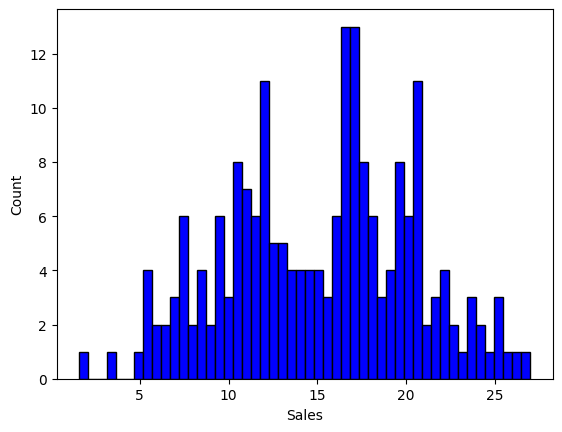

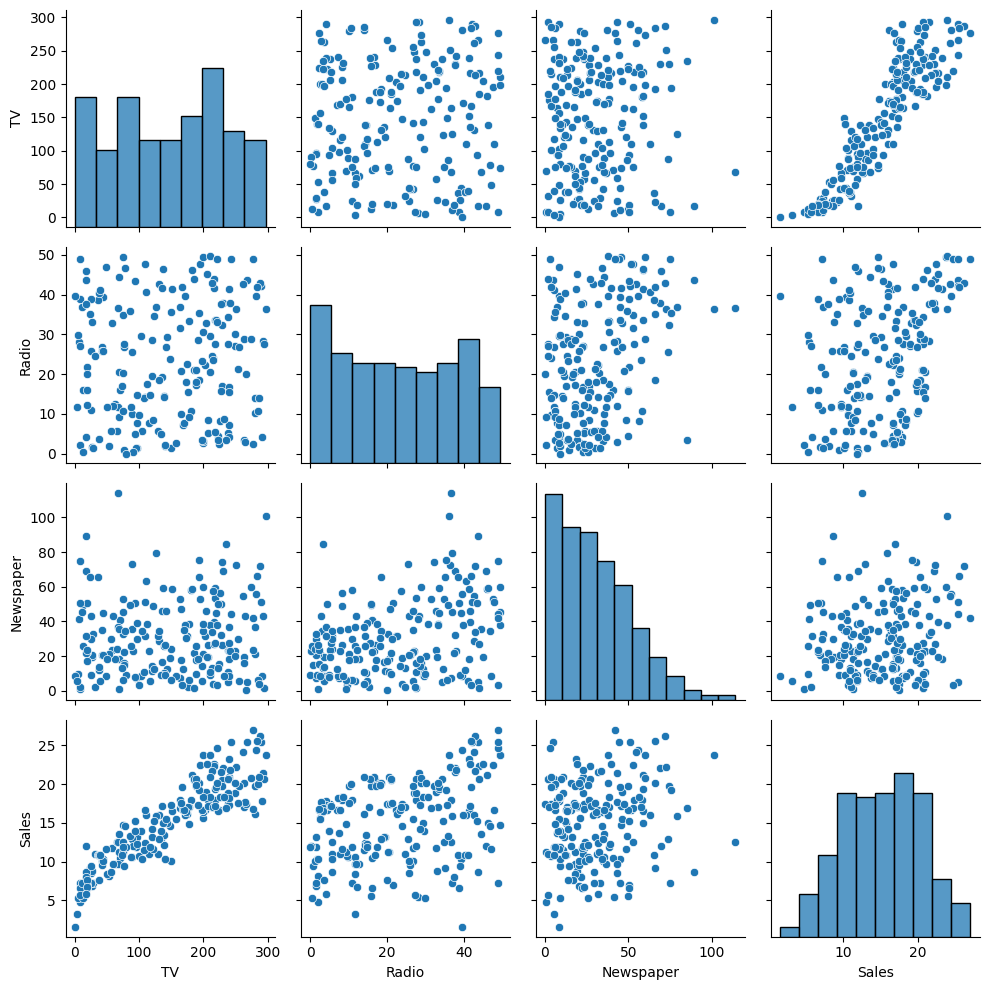

In [3]:
df=pd.read_csv('datasets/advertising.csv')
print(df.head())

print(df.isnull().sum().sum())



plt.hist(df['Sales'], bins=50, color='blue', edgecolor='black',)
plt.xlabel('Sales')
plt.ylabel('Count')


sns.pairplot(df)


plt.tight_layout()
plt.show()


X = df.drop('Sales',axis=1)
Y = df['Sales']




In [4]:
## Exploratory Data Analysis (EDA)

In [5]:
X_train,X_test,Y_train,Y_test =train_test_split(X,Y,test_size=0.2,random_state=42)
scalar =StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled =scalar.transform(X_test)

model = LinearRegression()

model.fit(X_train_scaled,Y_train)

Y_pred= model.predict(X_test_scaled)




MSE: 2.9077569102710923
R2 Score: 0.9059011844150826
15.330625000000003
[4.58720774 1.48984025 0.08791597]


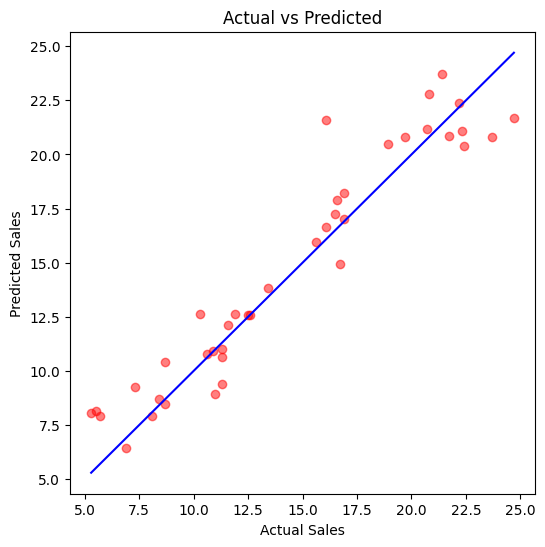

In [6]:
#Evaluation
mse = mean_squared_error(Y_test,Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("MSE:", mse)
print("R2 Score:", r2)


print(model.intercept_)
print(model.coef_)

plt.figure(figsize=(6,6))

plt.scatter(Y_test, Y_pred,color='red', alpha=0.5)

# Perfect prediction line
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color='blue')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()